In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/persona.csv")
df.head()

,PRICE,SOURCE,SEX,COUNTRY,AGE
0,39,android,male,bra,17
1,39,android,male,bra,17
2,49,android,male,bra,17
3,29,android,male,tur,17
4,49,android,male,tur,17


### Görev1.1: persona.csv dosyasını okutunuz ve veri seti ile ilgili genel bilgileri gösteriniz.

In [3]:
df.shape

(5000, 5)

In [4]:
df.columns

Index(['PRICE', 'SOURCE', 'SEX', 'COUNTRY', 'AGE'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   PRICE    5000 non-null   int64 
 1   SOURCE   5000 non-null   object
 2   SEX      5000 non-null   object
 3   COUNTRY  5000 non-null   object
 4   AGE      5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 234.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PRICE,5000.0,34.1320,12.464897,9.0,29.0,39.0,39.0,59.0
AGE,5000.0,23.5814,8.995908,15.0,17.0,21.0,27.0,66.0


In [7]:
df.isnull().sum()

PRICE      0
SOURCE     0
SEX        0
COUNTRY    0
AGE        0
dtype: int64

### Görev1.2: Kaç unique SOURCE vardır? Frekansları nedir?

In [8]:
df["SOURCE"].unique()

array(['android', 'ios'], dtype=object)

In [9]:
df["SOURCE"].nunique()

2

In [11]:
df["SOURCE"].value_counts()

SOURCE
android    2974
ios        2026
Name: count, dtype: int64

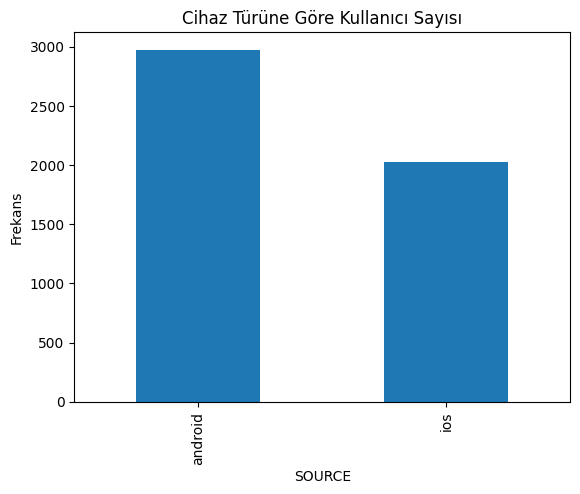

In [10]:
df["SOURCE"].value_counts().plot(kind="bar")
plt.title("Cihaz Türüne Göre Kullanıcı Sayısı")
plt.xlabel("SOURCE")
plt.ylabel("Frekans")
plt.show()

### Görev1.3: Kaç unique PRICE vardır?

In [11]:
df["PRICE"].unique()

array([39, 49, 29, 19, 59,  9])

In [12]:
df["PRICE"].nunique()

6

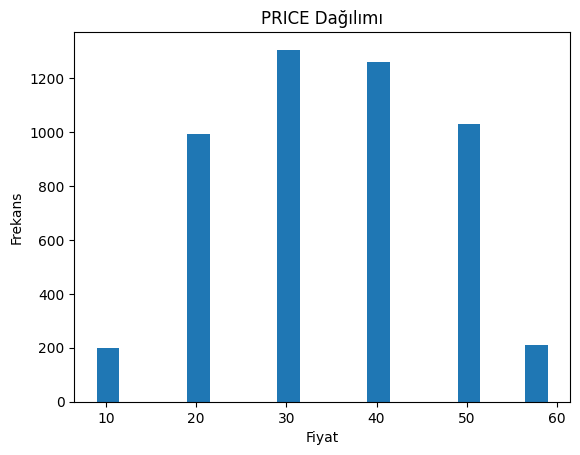

In [13]:
plt.hist(df["PRICE"], bins=20)
plt.title("PRICE Dağılımı")
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.show()

### Görev1.4: Hangi PRICE'dan kaçar tane satış gerçekleşmiş?

In [14]:
df["PRICE"].value_counts()

PRICE
29    1305
39    1260
49    1031
19     992
59     212
9      200
Name: count, dtype: int64

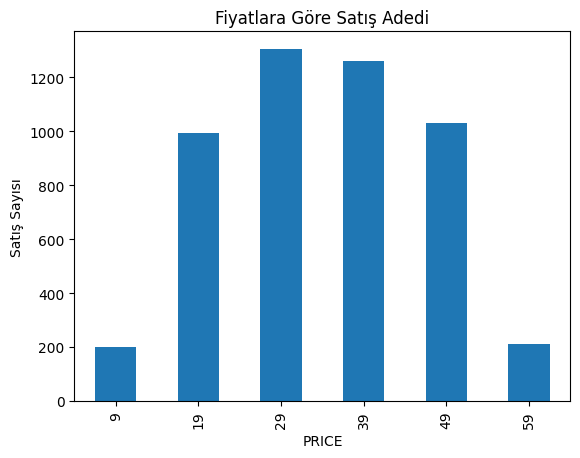

In [15]:
df["PRICE"].value_counts().sort_index().plot(kind="bar")
plt.title("Fiyatlara Göre Satış Adedi")
plt.xlabel("PRICE")
plt.ylabel("Satış Sayısı")
plt.show()

### Görev1.5: Hangi ülkeden kaçar tane satış olmuş?

In [16]:
df["COUNTRY"].value_counts()

COUNTRY
usa    2065
bra    1496
deu     455
tur     451
fra     303
can     230
Name: count, dtype: int64

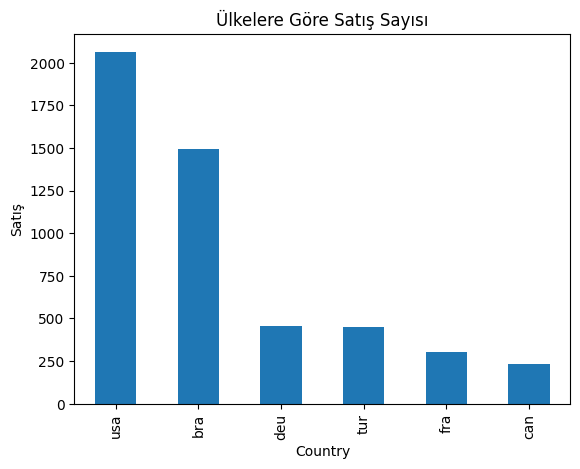

In [17]:
df["COUNTRY"].value_counts().plot(kind="bar")
plt.title("Ülkelere Göre Satış Sayısı")
plt.xlabel("Country")
plt.ylabel("Satış")
plt.show()

### Görev1.6: Ülkelere göre satışlardan toplam ne kadar kazanılmış?

In [18]:
df.groupby("COUNTRY")["PRICE"].sum()

COUNTRY
bra    51354
can     7730
deu    15485
fra    10177
tur    15689
usa    70225
Name: PRICE, dtype: int64

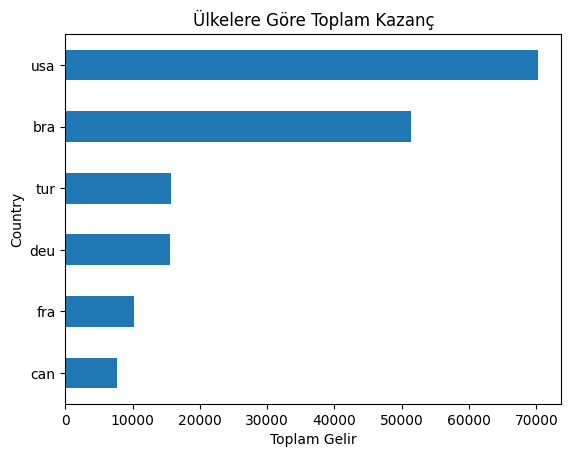

In [27]:
df.groupby("COUNTRY")["PRICE"].sum().sort_values().plot(kind="barh")
plt.title("Ülkelere Göre Toplam Kazanç")
plt.xlabel("Toplam Gelir")
plt.ylabel("Country")
plt.show()

### Görev1.7: SOURCE türlerine göre göre satış sayıları nedir?

In [28]:
df.groupby("SOURCE")["PRICE"].count()

SOURCE
android    2974
ios        2026
Name: PRICE, dtype: int64

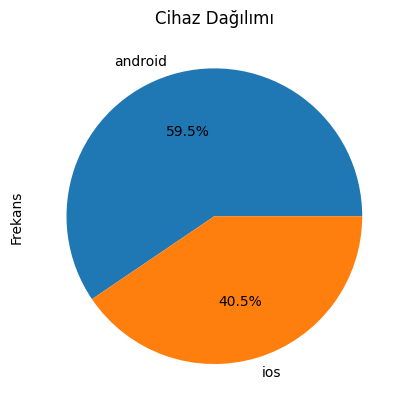

In [29]:
df["SOURCE"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Cihaz Dağılımı")
plt.ylabel("Frekans")
plt.show()

### Görev1.8: Ülkelere göre PRICE ortalamaları nedir?

In [30]:
df.groupby("COUNTRY")["PRICE"].mean()

COUNTRY
bra    34.327540
can    33.608696
deu    34.032967
fra    33.587459
tur    34.787140
usa    34.007264
Name: PRICE, dtype: float64

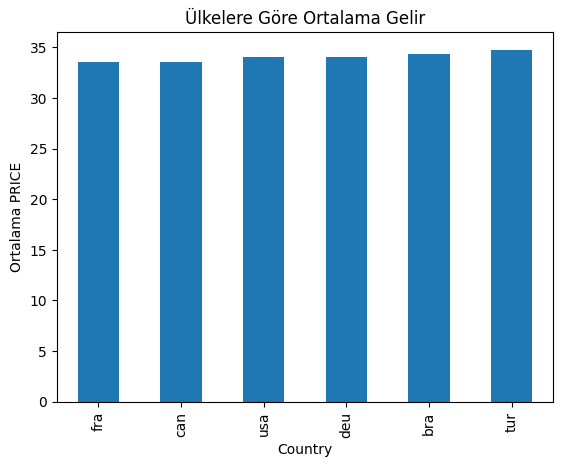

In [31]:
df.groupby("COUNTRY")["PRICE"].mean().sort_values().plot(kind="bar")
plt.title("Ülkelere Göre Ortalama Gelir")
plt.xlabel("Country")
plt.ylabel("Ortalama PRICE")
plt.show()

### Görev1.9: SOURCE'lara göre PRICE ortalamaları nedir?

In [32]:
df.groupby("SOURCE")["PRICE"].mean()

SOURCE
android    34.174849
ios        34.069102
Name: PRICE, dtype: float64

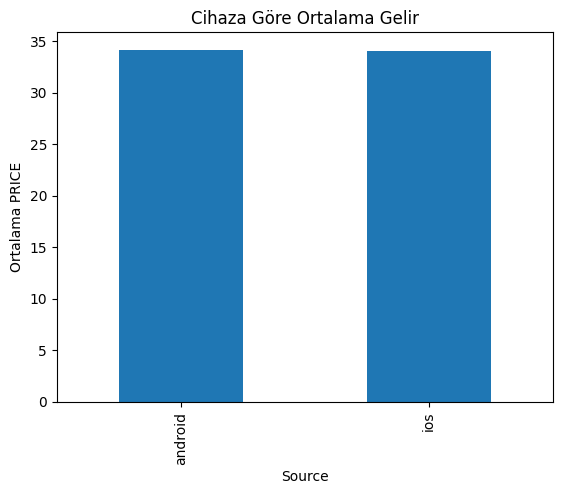

In [33]:
df.groupby("SOURCE")["PRICE"].mean().plot(kind="bar")
plt.title("Cihaza Göre Ortalama Gelir")
plt.xlabel("Source")
plt.ylabel("Ortalama PRICE")
plt.show()

### Görev1.10: COUNTRY-SOURCE kırılımında PRICE ortalamaları nedir?

In [20]:
df.groupby(["COUNTRY", "SOURCE"])["PRICE"].mean()

COUNTRY  SOURCE 
bra      android    34.387029
         ios        34.222222
can      android    33.330709
         ios        33.951456
deu      android    33.869888
         ios        34.268817
fra      android    34.312500
         ios        32.776224
tur      android    36.229437
         ios        33.272727
usa      android    33.760357
         ios        34.371703
Name: PRICE, dtype: float64

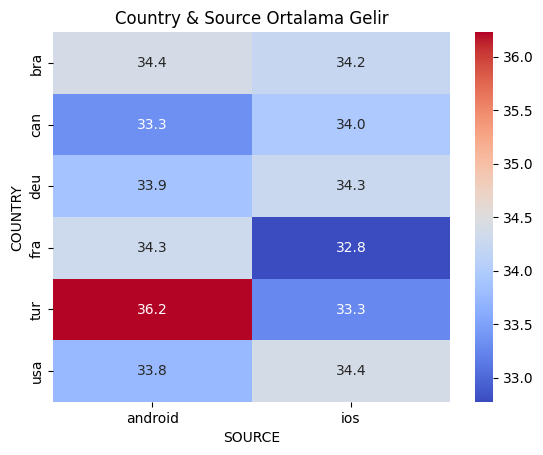

In [38]:
pivot = df.pivot_table(values="PRICE", index="COUNTRY", columns="SOURCE", aggfunc="mean")

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Country & Source Ortalama Gelir")
plt.show()

### Görev2: COUNTRY, SOURCE, SEX, AGE kırılımında ortalama kazançlar nedir?

In [39]:
agg_df = df.groupby(["COUNTRY", "SOURCE", "SEX", "AGE"]).agg({"PRICE": "mean"})

In [40]:
agg_df

PRICE
COUNTRY SOURCE  SEX    AGE           
bra     android female 15   38.714286
                       16   35.944444
                       17   35.666667
                       18   32.255814
                       19   35.206897
...                               ...
usa     ios     male   42   30.250000
                       50   39.000000
                       53   34.000000
                       55   29.000000
                       59   46.500000

[348 rows x 1 columns]

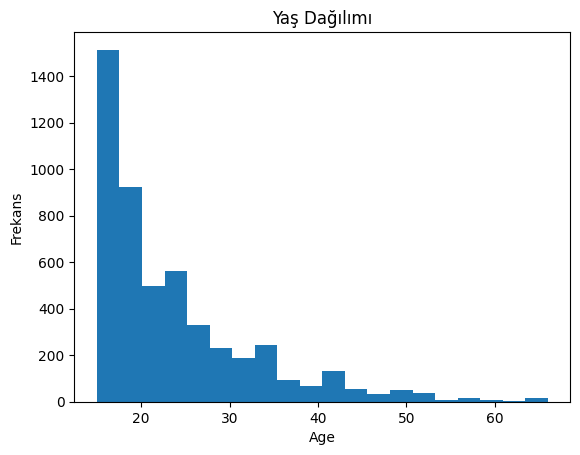

In [41]:
plt.hist(df["AGE"], bins=20)
plt.title("Yaş Dağılımı")
plt.xlabel("Age")
plt.ylabel("Frekans")
plt.show()

### Görev3: Çıktıyı PRICE’a göre sıralayınız.

In [26]:
agg_df = agg_df.sort_values("PRICE", ascending=False)
agg_df.head()

,,,,PRICE
COUNTRY,SOURCE,SEX,AGE,
usa,android,male,36,59.0
bra,android,male,46,59.0
fra,android,female,24,59.0
usa,ios,male,32,54.0
fra,ios,male,20,49.0


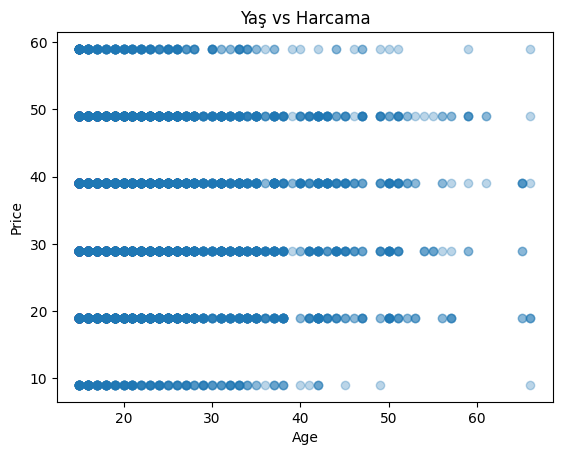

In [42]:
plt.scatter(df["AGE"], df["PRICE"], alpha=0.3)
plt.title("Yaş vs Harcama")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

### Görev4: Index’te yer alan isimleri değişken ismine çeviriniz.

In [44]:
agg_df = agg_df.reset_index()
agg_df.head()

,COUNTRY,SOURCE,SEX,AGE,PRICE
0,bra,android,female,15,38.714286
1,bra,android,female,16,35.944444
2,bra,android,female,17,35.666667
3,bra,android,female,18,32.255814
4,bra,android,female,19,35.206897


### Görev5: age değişkenini kategorik değişkene çeviriniz ve agg_df’e ekleyiniz.

In [45]:
sinirlar = [0, 18, 23, 30, 40, 70]
aralik_isimleri = ["0_18", "19_23", "24_30", "31_40", "41_70"]

agg_df["AGE_CAT"] = pd.cut(agg_df["AGE"], bins=sinirlar, labels=aralik_isimleri)

In [46]:
agg_df.head()

,COUNTRY,SOURCE,SEX,AGE,PRICE,AGE_CAT
0,bra,android,female,15,38.714286,0_18
1,bra,android,female,16,35.944444,0_18
2,bra,android,female,17,35.666667,0_18
3,bra,android,female,18,32.255814,0_18
4,bra,android,female,19,35.206897,19_23


### Görev6: Yeni seviye tabanlı müşterileri (persona) tanımlayınız.

In [47]:
agg_df["customers_level_based"] = (
    agg_df["COUNTRY"].str.upper() + "_" +
    agg_df["SOURCE"].str.upper() + "_" +
    agg_df["SEX"].str.upper() + "_" + 
    agg_df["AGE_CAT"].astype(str)
)

In [48]:
agg_df[["customers_level_based", "PRICE"]].head()

,customers_level_based,PRICE
0,BRA_ANDROID_FEMALE_0_18,38.714286
1,BRA_ANDROID_FEMALE_0_18,35.944444
2,BRA_ANDROID_FEMALE_0_18,35.666667
3,BRA_ANDROID_FEMALE_0_18,32.255814
4,BRA_ANDROID_FEMALE_19_23,35.206897


### Görev6.1: Tekilleştirme (Aynı olan customers'lar için ortalama almak).

In [49]:
final_df = agg_df.groupby("customers_level_based").agg({"PRICE": "mean"}).reset_index()
final_df.head()

,customers_level_based,PRICE
0,BRA_ANDROID_FEMALE_0_18,35.645303
1,BRA_ANDROID_FEMALE_19_23,34.077340
2,BRA_ANDROID_FEMALE_24_30,33.863946
3,BRA_ANDROID_FEMALE_31_40,34.898326
4,BRA_ANDROID_FEMALE_41_70,36.737179


### Görev7: Yeni müşterileri (personaları) segmentlere ayırınız. (qcut price değerini 4 eşit parçaya böldü)

In [61]:
final_df["SEGMENT"] = pd.qcut(final_df["PRICE"], 4, labels=["D", "C", "B", "A"])
final_df.head()

,customers_level_based,PRICE,SEGMENT
0,BRA_ANDROID_FEMALE_0_18,35.645303,B
1,BRA_ANDROID_FEMALE_19_23,34.077340,C
2,BRA_ANDROID_FEMALE_24_30,33.863946,C
3,BRA_ANDROID_FEMALE_31_40,34.898326,B
4,BRA_ANDROID_FEMALE_41_70,36.737179,A


In [62]:
final_df.groupby("SEGMENT").agg({"PRICE": ["mean", "max", "sum"]})

/tmp/ipykernel_3071/3780764835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby("SEGMENT").agg({"PRICE": ["mean", "max", "sum"]})


PRICE                        
              mean        max          sum
SEGMENT                                   
D        29.206780  32.333333   817.789833
C        33.509674  34.077340   904.761209
B        34.999645  36.000000   944.990411
A        38.691234  45.428571  1044.663328

In [63]:
c_segment = final_df[final_df["SEGMENT"] == "C"]
c_segment

,customers_level_based,PRICE,SEGMENT
1,BRA_ANDROID_FEMALE_19_23,34.077340,C
2,BRA_ANDROID_FEMALE_24_30,33.863946,C
7,BRA_ANDROID_MALE_24_30,33.413919,C
12,BRA_IOS_FEMALE_24_30,34.015873,C
17,BRA_IOS_MALE_24_30,33.864865,C
23,CAN_ANDROID_FEMALE_41_70,34.000000,C
35,DEU_ANDROID_FEMALE_19_23,33.333333,C
36,DEU_ANDROID_FEMALE_24_30,33.569129,C
44,DEU_IOS_FEMALE_19_23,34.000000,C
45,DEU_IOS_FEMALE_24_30,32.500000,C


### Görev7.1: Yeni gelen müşterileri segmentlerine göre sınıflandırınız ve ne kadar gelir getirebileceğini tahmin ediniz. (Türkiye, 33 yaşında, Android)

In [64]:
new_user = "TUR_ANDROID_FEMALE_31_40"

final_df[final_df["customers_level_based"] == new_user]

,customers_level_based,PRICE,SEGMENT
72,TUR_ANDROID_FEMALE_31_40,41.833333,A


### Görev7.2: 35 yaşında, IOS, fransız kadın.

In [65]:
fra_user = "FRA_IOS_FEMALE_31_40"

final_df[final_df["customers_level_based"] == fra_user]

,customers_level_based,PRICE,SEGMENT
63,FRA_IOS_FEMALE_31_40,32.818182,C
